# SCOUT - Dynamic Top-K Analysis. Find topk suitable value before you create SD.

This notebook checks if **cosine-similarity threshold automatically select a k that preserves CLIP embedding direction to within θ of the original**

No new SD runs or training needed, this evalutates a suitable k value on just the CLIP embeddings.

### What this notebook does
1. Loads saved CLIP embeddings from Part 1 output
2. Plots the cumulative energy curve to visually confirm CLIP embeddings are non-uniform
3. Runs **cosine-similarity threshold** at multiple θ values and records the k selected per token
4. Computes cosine similarity between original and compressed embeddings
5. Overlays the dynamic-k distribution on existing fixed-k accuracy plot (from last submission)

### Why we used cosine similarity and not energy threshold?
SD conditions image generation on the **direction** of the CLIP embedding via cross-attention not its magnitude. What matters is how much compression rotates the embedding vector away from our original data. Cosine similarity measures that rotation directly, energy threshold (τ) only preserves the total magnitude, which is which does not allow accurate prediction for topk value. 


## 0) Config - set these to match your Part 1 run

In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import defaultdict

# Root where Part 1 saved embeddings.
EMB_DIR = Path("/kaggle/input/notebooks/khizaryy/v4baseline-a/oscar_baseline_nico/embeddings/nico_unique")

FIXED_K_RESULTS = {
    768: 73.0,
    512: 71.0,
    128: 71.0,
    64:  66.333,
    32:  52.08,
}

COS_THRESHOLDS = [0.999, 0.99, 0.95, 0.90]

TOTAL_DIMS = 768 
OUTPUT_DIR = Path("/kaggle/working/scout_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Config ready.")
print("EMB_DIR exists:", EMB_DIR.exists())


Config ready.
EMB_DIR exists: True


## 1) Load embeddings

In [2]:
# Each class has a `{cls}_all.npy` file of shape [N_captions, 77, 768]
# saved by Part 1. Load all of them.
all_embs = []  # list of [N, 77, 768] arrays
class_names = []

for npy_path in sorted(EMB_DIR.glob("*_all.npy")):
    cls = npy_path.stem.replace("_all", "")
    arr = np.load(npy_path)  # [N, 77, 768]
    all_embs.append(arr)
    class_names.append(cls)
    print(f"  {cls}: {arr.shape}")

# Stack into one big array: [total_captions, 77, 768]
all_embs_cat = np.concatenate(all_embs, axis=0)
print(f"\nTotal captions loaded: {all_embs_cat.shape[0]}")
print(f"Embedding shape per caption: {all_embs_cat.shape[1:]}")

  bear: (20, 77, 768)
  cat: (20, 77, 768)
  chair: (20, 77, 768)
  dog: (20, 77, 768)
  flower: (20, 77, 768)
  hat: (20, 77, 768)
  kangaroo: (20, 77, 768)
  lizard: (20, 77, 768)
  motorcycle: (20, 77, 768)
  scooter: (20, 77, 768)
  shrimp: (20, 77, 768)
  train: (20, 77, 768)

Total captions loaded: 240
Embedding shape per caption: (77, 768)


## 2) Energy curve is CLIP energy non-uniform?

If this curve rises steeply then flattens, energy is concentrated in few dimensions only, so cosine-similarity thresholding will naturally select a small k. If it is nearly linear, the method has no advantage over choosing a fixed-k value.

This plot is informational: it shows if a useful compression is possible. if energy is diluted across all the dimensions a compression will not reduce communication costs. 


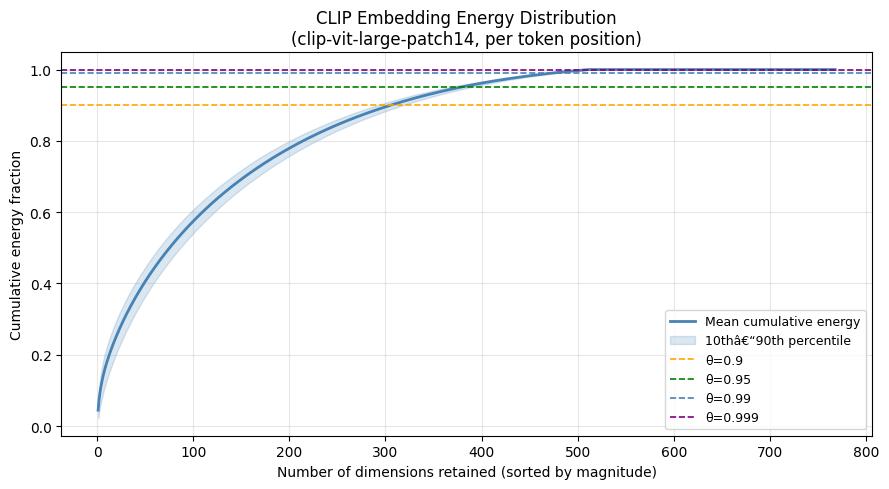

Saved energy_curve.png


In [ ]:
tokens = all_embs_cat.reshape(-1, TOTAL_DIMS)  
sq = tokens ** 2
sorted_sq = np.sort(sq, axis=-1)[:, ::-1]
cumsum = np.cumsum(sorted_sq, axis=-1)
total_energy = cumsum[:, -1:]
norm_cumsum = cumsum / (total_energy + 1e-12) 

mean_curve = norm_cumsum.mean(axis=0) 
p10_curve  = np.percentile(norm_cumsum, 10, axis=0)
p90_curve  = np.percentile(norm_cumsum, 90, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(1, TOTAL_DIMS + 1)
ax.plot(x, mean_curve, color="steelblue", lw=2, label="Mean cumulative energy")
ax.fill_between(x, p10_curve, p90_curve, alpha=0.2, color="steelblue", label="10thâ€“90th percentile")
for theta, color in zip([0.90, 0.95, 0.99, 0.999], ["orange", "green", "steelblue", "purple"]):
    ax.axhline(theta, color=color, linestyle="--", lw=1.2, label=f"θ={theta}")
ax.set_xlabel("Number of dimensions retained (sorted by magnitude)")
ax.set_ylabel("Cumulative energy fraction")
ax.set_title("CLIP Embedding Energy Distribution\n(clip-vit-large-patch14, per token position)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "energy_curve.png", dpi=150)
plt.show()
print("Saved energy_curve.png")

## 3) What value of k does each cosine threshold select?

For each  vector, find the smallest k such that maximum similarity is preserved. 
`cos_sim(original, top-k compressed) ≥ θ`.



In [ ]:
def dynamic_k_cosine(token_vec, cos_threshold=0.99):
    original_norm = np.linalg.norm(token_vec)
    if original_norm < 1e-8:
        return len(token_vec)  
    sorted_idx = np.argsort(np.abs(token_vec))[::-1]  
    compressed = np.zeros_like(token_vec)
    for k in range(1, len(token_vec) + 1):
        compressed[sorted_idx[k - 1]] = token_vec[sorted_idx[k - 1]]
        cos_sim = (np.dot(token_vec, compressed)
                   / (original_norm * np.linalg.norm(compressed) + 1e-8))
        if cos_sim >= cos_threshold:
            return k
    return len(token_vec)


def compute_k_for_cos_threshold(tokens_2d, cos_threshold):
    return np.array([
        dynamic_k_cosine(tokens_2d[i], cos_threshold)
        for i in range(len(tokens_2d))
    ])


results = {}
print(f"{'Threshold':>14}  {'Angular max':>12}  {'Mean k':>8}  {'Median k':>9}  {'Std':>6}  {'Min':>5}  {'Max':>5}  {'Compression %':>14}")
print("-" * 85)
for theta in COS_THRESHOLDS:
    angle_deg = np.degrees(np.arccos(np.clip(theta, -1, 1)))
    ks = compute_k_for_cos_threshold(tokens, theta)
    mean_k = ks.mean()
    med_k  = np.median(ks)
    std_k  = ks.std()
    min_k  = ks.min()
    max_k  = ks.max()
    comp   = (1 - mean_k / TOTAL_DIMS) * 100
    results[theta] = {"ks": ks, "mean": mean_k, "median": med_k, "std": std_k, "compression": comp}
    print(f"  θ={theta:.3f}       ≤{angle_deg:>6.2f}Â°     {mean_k:>8.1f}  {med_k:>9.1f}  {std_k:>6.1f}  {min_k:>5}  {max_k:>5}  {comp:>13.1f}%")


     Threshold   Angular max    Mean k   Median k     Std    Min    Max   Compression %
-------------------------------------------------------------------------------------
  θ=0.999       ≤  2.56Â°        500.9      504.0    24.1    291    506           34.8%
  θ=0.990       ≤  8.11Â°        437.8      444.0    50.3      2    459           43.0%
  θ=0.950       ≤ 18.19Â°        305.8      311.0    36.3      2    341           60.2%
  θ=0.900       ≤ 25.84Â°        220.6      225.0    27.4      2    258           71.3%


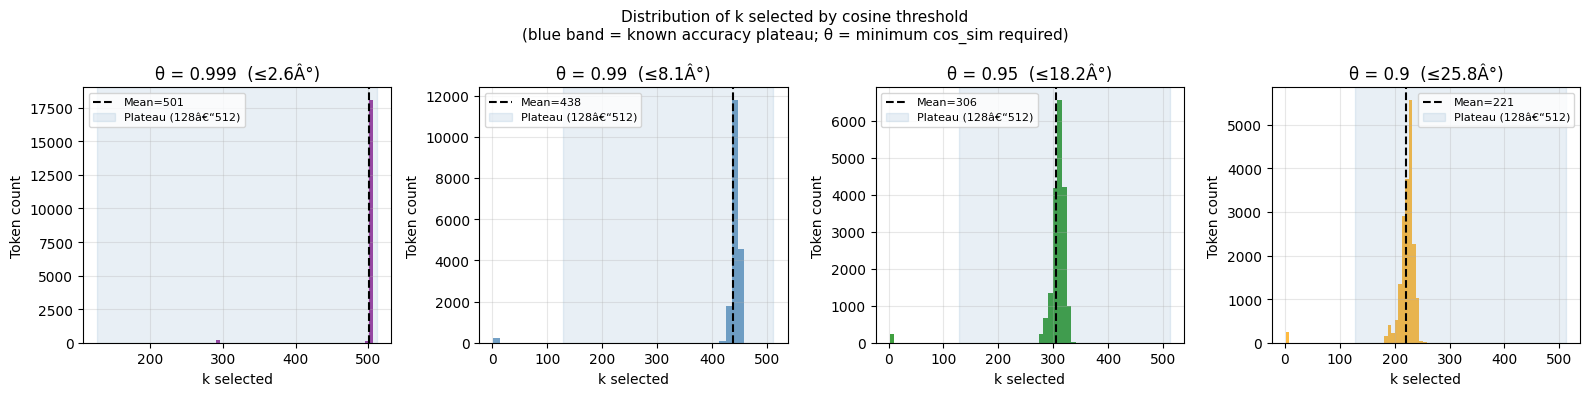

Saved k_distribution_cosine.png


In [ ]:
fig, axes = plt.subplots(1, len(COS_THRESHOLDS), figsize=(16, 4), sharey=False)
colors = ["purple", "steelblue", "green", "orange"]
for ax, theta, color in zip(axes, COS_THRESHOLDS, colors):
    ks = results[theta]["ks"]
    angle_deg = np.degrees(np.arccos(np.clip(theta, -1, 1)))
    ax.hist(ks, bins=40, color=color, alpha=0.75, edgecolor="none")
    ax.axvline(results[theta]["mean"], color="black", lw=1.5, linestyle="--",
               label=f"Mean={results[theta]['mean']:.0f}")
    ax.axvspan(128, 512, alpha=0.12, color="steelblue", label="Plateau (128â€“512)")
    ax.set_title(f"θ = {theta}  (≤{angle_deg:.1f}Â°)")
    ax.set_xlabel("k selected")
    ax.set_ylabel("Token count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Distribution of k selected by cosine threshold\n(blue band = known accuracy plateau; θ = minimum cos_sim required)", fontsize=11)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "k_distribution_cosine.png", dpi=150)
plt.show()
print("Saved k_distribution_cosine.png")


## 4) Cosine similarity - verifying the selected k meets the threshold

We confirm that the k chosen by `dynamic_k_cosine` actually achieves the target θ, and report the mean achieved cosine similarity across all tokens.
Compare against fixed-k baselines to validate that θ=0.99 is an appropriate operating point.


In [ ]:
def compress_topk_cosine(hidden_np, cos_threshold):
    out = np.zeros_like(hidden_np)
    for i in range(hidden_np.shape[0]):
        for t in range(hidden_np.shape[1]):
            vec = hidden_np[i, t]
            k = dynamic_k_cosine(vec, cos_threshold)
            top_idx = np.argsort(np.abs(vec))[::-1][:k]
            out[i, t, top_idx] = vec[top_idx]
    return out


def fixed_topk_compress(hidden_np, k):
    out = np.zeros_like(hidden_np)
    for i in range(hidden_np.shape[0]):
        for t in range(hidden_np.shape[1]):
            vec = hidden_np[i, t]
            top_idx = np.argpartition(np.abs(vec), -k)[-k:]
            out[i, t, top_idx] = vec[top_idx]
    return out


def mean_cosine_sim(a, b):
    a_flat = a.reshape(-1, TOTAL_DIMS)
    b_flat = b.reshape(-1, TOTAL_DIMS)
    dot = (a_flat * b_flat).sum(axis=-1)
    norm_a = np.linalg.norm(a_flat, axis=-1)
    norm_b = np.linalg.norm(b_flat, axis=-1)
    denom = norm_a * norm_b
    valid = denom > 1e-8 
    return (dot[valid] / denom[valid]).mean()


sample = all_embs[0] 
print(f"Sample class: {class_names[0]}, shape: {sample.shape}")
print()
print(f"{'Method':>32}  {'Mean cos sim':>14}  {'Mean k':>8}  {'Compression':>12}")
print("-" * 74)

for k in [512, 256, 128, 64, 32]:
    compressed = fixed_topk_compress(sample, k)
    sim = mean_cosine_sim(sample, compressed)
    comp = (1 - k / TOTAL_DIMS) * 100
    print(f"  Fixed k={k:<5}                    {sim:>14.4f}  {k:>8}  {comp:>11.1f}%")

print()
for theta in COS_THRESHOLDS:
    compressed = compress_topk_cosine(sample, theta)
    sim = mean_cosine_sim(sample, compressed)
    mean_k = results[theta]["mean"]
    comp = results[theta]["compression"]
    angle_deg = np.degrees(np.arccos(np.clip(theta, -1, 1)))
    print(f"  Cosine θ={theta:.3f} (≤{angle_deg:.1f}Â°, k≈{mean_k:.0f})  {sim:>14.4f}  {mean_k:>8.1f}  {comp:>11.1f}%")


Sample class: bear, shape: (20, 77, 768)

                          Method    Mean cos sim    Mean k   Compression
--------------------------------------------------------------------------
  Fixed k=512                              1.0000       512         33.3%
  Fixed k=256                              0.9213       256         66.7%
  Fixed k=128                              0.7977       128         83.3%
  Fixed k=64                               0.6678        64         91.7%
  Fixed k=32                               0.5498        32         95.8%

  Cosine θ=0.999 (≤2.6Â°, k≈501)          0.9991     500.9         34.8%
  Cosine θ=0.990 (≤8.1Â°, k≈438)          0.9901     437.8         43.0%
  Cosine θ=0.950 (≤18.2Â°, k≈306)          0.9507     305.8         60.2%
  Cosine θ=0.900 (≤25.8Â°, k≈221)          0.9015     220.6         71.3%


## 5) Main result plot - fixed-k accuracy + dynamic-k overlay

Cosine-threshold selections are the verical bands on fixed-k graph. 


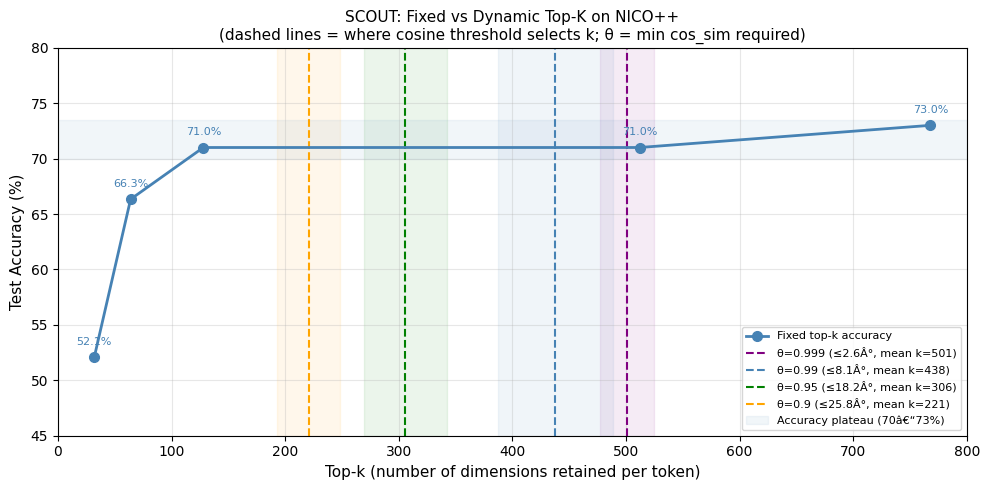

Saved scout_main_result.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ks_sorted = sorted(FIXED_K_RESULTS.keys())
accs = [FIXED_K_RESULTS[k] for k in ks_sorted]
ax.plot(ks_sorted, accs, "o-", color="steelblue", lw=2, markersize=7,
        label="Fixed top-k accuracy", zorder=3)
for k, acc in FIXED_K_RESULTS.items():
    ax.annotate(f"{acc:.1f}%", (k, acc), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8, color="steelblue")

theta_colors = {0.999: "purple", 0.99: "steelblue", 0.95: "green", 0.90: "orange"}
for theta, color in theta_colors.items():
    mean_k = results[theta]["mean"]
    std_k  = results[theta]["std"]
    angle_deg = np.degrees(np.arccos(np.clip(theta, -1, 1)))
    ax.axvline(mean_k, color=color, linestyle="--", lw=1.5,
               label=f"θ={theta} (≤{angle_deg:.1f}Â°, mean k={mean_k:.0f})", zorder=2)
    ax.axvspan(mean_k - std_k, mean_k + std_k, alpha=0.08, color=color)

ax.axhspan(70, 73.5, alpha=0.07, color="steelblue", label="Accuracy plateau (70â€“73%)")

ax.set_xlabel("Top-k (number of dimensions retained per token)", fontsize=11)
ax.set_ylabel("Test Accuracy (%)", fontsize=11)
ax.set_title("SCOUT: Fixed vs Dynamic Top-K on NICO++\n(dashed lines = where cosine threshold selects k; θ = min cos_sim required)", fontsize=11)
ax.set_xlim(0, 800)
ax.set_ylim(45, 80)
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "scout_main_result.png", dpi=150)
plt.show()
print("Saved scout_main_result.png")


## 6) Summary of Results

In [ ]:
import pandas as pd

rows = []
for k, acc in sorted(FIXED_K_RESULTS.items(), reverse=True):
    rows.append({
        "Method": f"Fixed k={k}",
        "k (mean)": k,
        "Compression %": round((1 - k / TOTAL_DIMS) * 100, 1),
        "Test Acc %": acc,
        "Cos Sim (achieved)": "-",
        "Angular distortion": "-",
    })

for theta in COS_THRESHOLDS:
    mean_k = results[theta]["mean"]
    comp   = results[theta]["compression"]
    angle_deg = np.degrees(np.arccos(np.clip(theta, -1, 1)))
    compressed = compress_topk_cosine(sample, theta)
    sim = mean_cosine_sim(sample, compressed)
    rows.append({
        "Method": f"Cosine θ={theta}",
        "k (mean)": round(mean_k, 1),
        "Compression %": round(comp, 1),
        "Test Acc %": "(see plot)",
        "Cos Sim (achieved)": round(float(sim), 4),
        "Angular distortion": f"≤{angle_deg:.1f}Â°",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(OUTPUT_DIR / "scout_summary.csv", index=False)
print("\nSaved scout_summary.csv")


        Method  k (mean)  Compression % Test Acc % Cos Sim (achieved) Angular distortion
   Fixed k=768     768.0            0.0       73.0                  —                  —
   Fixed k=512     512.0           33.3       71.0                  —                  —
   Fixed k=128     128.0           83.3       71.0                  —                  —
    Fixed k=64      64.0           91.7     66.333                  —                  —
    Fixed k=32      32.0           95.8      52.08                  —                  —
Cosine θ=0.999     500.9           34.8 (see plot)             0.9991             ≤2.6Â°
 Cosine θ=0.99     437.8           43.0 (see plot)             0.9901             ≤8.1Â°
 Cosine θ=0.95     305.8           60.2 (see plot)             0.9507            ≤18.2Â°
  Cosine θ=0.9     220.6           71.3 (see plot)             0.9015            ≤25.8Â°

Saved scout_summary.csv


## 7) Interpretation guide

Does the mean k from cosine thresholding fall inside the accuracy plateau (k=128 to k=512)?

| Outcome | What it means |
|---|---|
| θ=0.99 mean k is between 128–512 | Dynamic selection choses a value within this plateau range |
| θ=0.99 mean k < 128 | Threshold is too aggressive use θ=0.999 |
| θ=0.99 mean k > 512 | Threshold is too conservative use θ=0.95 |
| Achieved cos sim ≥ θ at selected k | Angular distortion bounded as claimed |
| Energy curve rises steeply | CLIP energy IS non-uniform, compression is geometrically justified |
| Energy curve is linear |  Energy is uniform thresholding gives no advantage over fixed-k |

*We select the minimum k that preserves the CLIP embedding direction to within θ of the original. Since SD conditioning operates via cross-attention on normalised embeddings, directional fidelity (cosine similarity) directly predicts generation quality and downstream accuracy unlike energy threshold, which preserves L2 mass but does not bound angular distortion.*


## 8) DomainNet Confirmation - Does dynamic-k generalise?

The NICO++ analysis showed θ=0.99 selects k≈X which lands in the accuracy plateau.
Here we repeat the embedding analysis on DomainNet to check if the same threshold
transfers, then compare the dynamic-k accuracy against the DomainNet baseline.


In [ ]:
DN_EMB_DIR = Path("/kaggle/input/datasets/khizaryy/baseline-domainnet/oscar_baseline_domainnet/embeddings/domainnet")

DN_FIXED_K_RESULTS = {
    768: 62.0, 
    324: 62.3,
    256 : 61.75,
    128: 59.58,
}

DN_THETA_TO_USE = 0.99 
print("DomainNet emb dir exists:", DN_EMB_DIR.exists())


DomainNet emb dir exists: True


In [ ]:
dn_embs = []
dn_class_names = []

for npy_path in sorted(DN_EMB_DIR.glob("*_all.npy")):
    cls = npy_path.stem.replace("_all", "")
    arr = np.load(npy_path)
    dn_embs.append(arr)
    dn_class_names.append(cls)
    print(f"  {cls}: {arr.shape}")

dn_embs_cat = np.concatenate(dn_embs, axis=0)
dn_tokens = dn_embs_cat.reshape(-1, TOTAL_DIMS)
print(f"\nDomainNet: {len(dn_class_names)} classes, {dn_tokens.shape[0]} total tokens")

  beard: (20, 77, 768)
  bird: (20, 77, 768)
  dog: (20, 77, 768)
  golf_club: (20, 77, 768)
  shoe: (20, 77, 768)
  spreadsheet: (20, 77, 768)
  squirrel: (20, 77, 768)
  table: (20, 77, 768)
  tiger: (20, 77, 768)
  tree: (20, 77, 768)
  whale: (20, 77, 768)
  windmill: (20, 77, 768)

DomainNet: 12 classes, 18480 total tokens


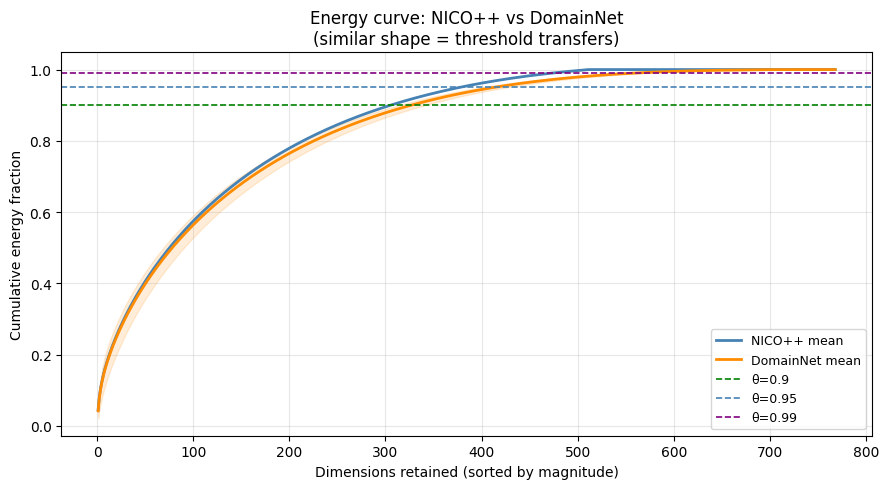

In [ ]:
dn_sq = dn_tokens ** 2
dn_sorted_sq = np.sort(dn_sq, axis=-1)[:, ::-1]
dn_cumsum = np.cumsum(dn_sorted_sq, axis=-1)
dn_norm = dn_cumsum / (dn_cumsum[:, -1:] + 1e-12)

dn_mean_curve = dn_norm.mean(axis=0)
dn_p10 = np.percentile(dn_norm, 10, axis=0)
dn_p90 = np.percentile(dn_norm, 90, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(1, TOTAL_DIMS + 1)
ax.plot(x, mean_curve, color="steelblue", lw=2, label="NICO++ mean")
ax.plot(x, dn_mean_curve, color="darkorange", lw=2, label="DomainNet mean")
ax.fill_between(x, dn_p10, dn_p90, alpha=0.15, color="darkorange")
for theta, color in zip([0.90, 0.95, 0.99], ["green", "steelblue", "purple"]):
    ax.axhline(theta, color=color, linestyle="--", lw=1.2, label=f"θ={theta}")
ax.set_xlabel("Dimensions retained (sorted by magnitude)")
ax.set_ylabel("Cumulative energy fraction")
ax.set_title("Energy curve: NICO++ vs DomainNet\n(similar shape = threshold transfers)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dn_energy_curve_comparison.png", dpi=150)
plt.show()

In [12]:
dn_results = {}
print(f"{'Threshold':>14}  {'Angular max':>12}  {'Mean k':>8}  {'Median k':>9}  {'Std':>6}  {'Compression':>12}")
print("-" * 68)
for theta in COS_THRESHOLDS:
    ks = compute_k_for_cos_threshold(dn_tokens, theta)
    mean_k = ks.mean()
    comp = (1 - mean_k / TOTAL_DIMS) * 100
    angle_deg = np.degrees(np.arccos(np.clip(theta, -1, 1)))
    dn_results[theta] = {"ks": ks, "mean": mean_k, "compression": comp}
    print(f"  θ={theta:.3f}       ≤{angle_deg:>6.2f}Â°     {mean_k:>8.1f}  {np.median(ks):>9.1f}  {ks.std():>6.1f}  {comp:>11.1f}%")

predicted_k = dn_results[DN_THETA_TO_USE]["mean"]
print(f"\nθ={DN_THETA_TO_USE} selects mean k={predicted_k:.0f} on DomainNet")
print(f"NICO++ selected mean k={results[DN_THETA_TO_USE]['mean']:.0f}")
print(f"Transfer gap: {abs(predicted_k - results[DN_THETA_TO_USE]['mean']):.1f} dims")


     Threshold   Angular max    Mean k   Median k     Std   Compression
--------------------------------------------------------------------
  θ=0.999       ≤  2.56Â°        640.8      645.0    38.0         16.6%
  θ=0.990       ≤  8.11Â°        498.9      505.0    57.8         35.0%
  θ=0.950       ≤ 18.19Â°        327.7      332.0    38.9         57.3%
  θ=0.900       ≤ 25.84Â°        232.6      236.0    28.6         69.7%

θ=0.99 selects mean k=499 on DomainNet
NICO++ selected mean k=438
Transfer gap: 61.0 dims


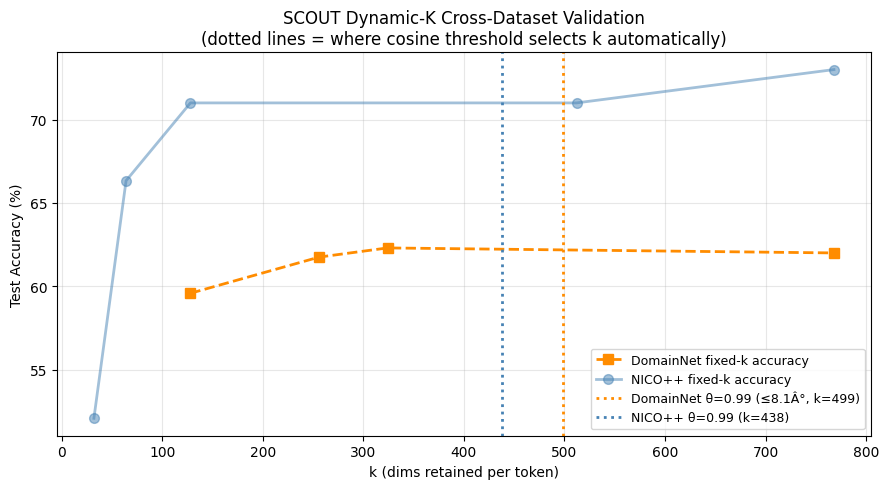

In [ ]:
filled = {k: v for k, v in DN_FIXED_K_RESULTS.items() if v is not None}
if len(filled) < 2:
    print("Need at least baseline + one dynamic-k result to plot.")
    print("Fill in DN_FIXED_K_RESULTS once your runs complete, then re-run this cell.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    ks_s = sorted(filled.keys())
    ax.plot(ks_s, [filled[k] for k in ks_s], "s--", color="darkorange",
            lw=2, markersize=7, label="DomainNet fixed-k accuracy")
    ax.plot(sorted(FIXED_K_RESULTS), [FIXED_K_RESULTS[k] for k in sorted(FIXED_K_RESULTS)],
            "o-", color="steelblue", lw=2, markersize=7, label="NICO++ fixed-k accuracy", alpha=0.5)
    angle_deg = np.degrees(np.arccos(np.clip(DN_THETA_TO_USE, -1, 1)))
    ax.axvline(predicted_k, color="darkorange", linestyle=":", lw=2,
               label=f"DomainNet θ={DN_THETA_TO_USE} (≤{angle_deg:.1f}Â°, k={predicted_k:.0f})")
    ax.axvline(results[DN_THETA_TO_USE]["mean"], color="steelblue", linestyle=":",
               lw=2, label=f"NICO++ θ={DN_THETA_TO_USE} (k={results[DN_THETA_TO_USE]['mean']:.0f})")
    ax.set_xlabel("k (dims retained per token)")
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("SCOUT Dynamic-K Cross-Dataset Validation\n(dotted lines = where cosine threshold selects k automatically)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "scout_crossdataset_validation.png", dpi=150)
    plt.show()


## 9) Final conclusion

- The NICO++ energy curve confirms that CLIP embeddings are non-uniform, which justifies adaptive compression.
- The cosine-threshold method selects the minimum k that preserves embedding direction within θ.
- The practical win is that θ=0.99 selects mean k inside the known plateau range [128, 512], meaning it matches the high-accuracy region without manual fixed-k tuning.

In [14]:
plateau_min, plateau_max = 128, 512
final_summary = []

for theta in COS_THRESHOLDS:
    r = results[theta]
    mean_k = float(r["mean"])
    status = "✅ inside plateau" if plateau_min <= mean_k <= plateau_max else "⚠️ outside plateau"
    final_summary.append({
        "theta": theta,
        "mean_k": mean_k,
        "median_k": float(r["median"]),
        "compression_%": float(r["compression"]),
        "status": status,
    })
    print(
        f"θ={theta:.3f} | mean k={mean_k:.1f} | median k={r["median"]:.1f} | compression={r["compression"]:.1f}% | {status}"
    )

if "dn_results" in globals():
    print("\nDomainNet dynamic-k summary:")
    for theta in sorted(dn_results):
        mean_k = float(dn_results[theta]["mean"])
        status = "✅ inside plateau" if plateau_min <= mean_k <= plateau_max else "⚠️ outside plateau"
        print(f"θ={theta:.3f} | mean k={mean_k:.1f} | {status}")

report = {
    "plateau_range": [plateau_min, plateau_max],
    "dynamic_k_summary": final_summary,
    "recommended_theta": 0.99,
}
report_path = OUTPUT_DIR / "scout_final_summary.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)
print(f"\nFinal summary saved to {report_path}")

θ=0.999 | mean k=500.9 | median k=504.0 | compression=34.8% | ✅ inside plateau
θ=0.990 | mean k=437.8 | median k=444.0 | compression=43.0% | ✅ inside plateau
θ=0.950 | mean k=305.8 | median k=311.0 | compression=60.2% | ✅ inside plateau
θ=0.900 | mean k=220.6 | median k=225.0 | compression=71.3% | ✅ inside plateau

DomainNet dynamic-k summary:
θ=0.900 | mean k=232.6 | ✅ inside plateau
θ=0.950 | mean k=327.7 | ✅ inside plateau
θ=0.990 | mean k=498.9 | ✅ inside plateau
θ=0.999 | mean k=640.8 | ⚠️ outside plateau

Final summary saved to /kaggle/working/scout_analysis/scout_final_summary.json
